In [76]:
%pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [77]:
%pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [78]:
%pip install load_dotenv

Note: you may need to restart the kernel to use updated packages.


In [79]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [80]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [81]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [82]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [83]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# SHOWER LOG

In [84]:
import pandas as pd

query = "SELECT * FROM SHOWER_LOG"
df = pd.read_sql(query, engine)

In [85]:
df.head()

,USER_ID,DAY_ID,SHOWER_START,SHOWER_DURING,SHOWER_TEMP
0,1,1,0 days 15:00:00,long,hot
1,1,2,0 days 13:00:00,long,hot
2,1,3,0 days 08:00:00,long,warm
3,1,3,0 days 20:30:00,short,hot
4,1,4,0 days 13:00:00,long,hot


In [86]:
print(df.describe())

       USER_ID     DAY_ID               SHOWER_START
count     13.0  13.000000                         13
mean       1.0   5.846154  0 days 12:24:13.846153846
std        0.0   3.158221  0 days 04:52:18.605768637
min        1.0   1.000000            0 days 06:15:00
25%        1.0   3.000000            0 days 08:15:00
50%        1.0   6.000000            0 days 13:00:00
75%        1.0   8.000000            0 days 13:30:00
max        1.0  11.000000            0 days 22:00:00


In [87]:
import matplotlib.pyplot as plt

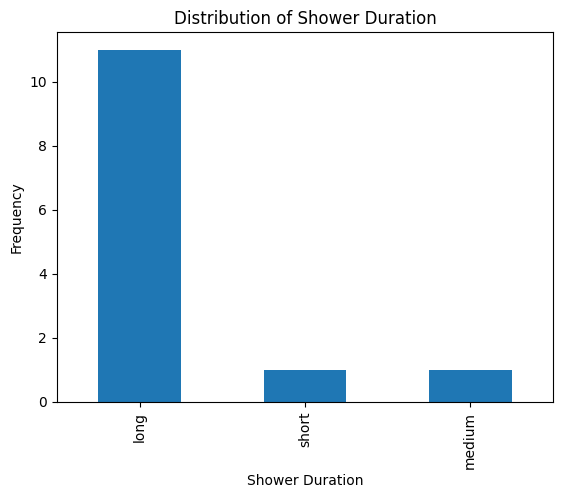

In [88]:
df['SHOWER_DURING'].value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel("Shower Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Shower Duration")
plt.show()

# PHONE SCREEN

In [89]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL`, `SCREEN_TIME` - `SOCIAL` AS `OTHERS` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [90]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS
0,2025-06-20,399.0,353.0,46.0
1,2025-06-21,226.0,117.0,109.0
2,2025-06-22,274.0,195.0,79.0
3,2025-06-23,300.0,206.0,94.0
4,2025-06-24,123.0,113.0,10.0


In [91]:
print(ps[['SCREEN_TIME','SOCIAL', 'OTHERS']].describe())

       SCREEN_TIME      SOCIAL      OTHERS
count    10.000000   10.000000   10.000000
mean    264.100000  148.300000  115.800000
std      89.450731   86.520454   70.370133
min     123.000000   47.000000   10.000000
25%     218.500000   98.000000   73.750000
50%     259.000000  116.000000  101.500000
75%     302.250000  184.500000  164.500000
max     399.000000  353.000000  240.000000


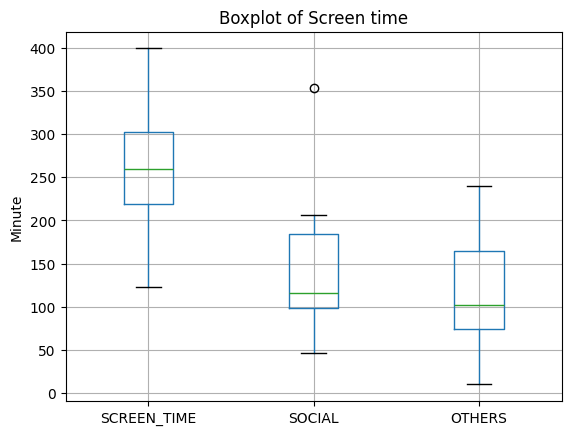

In [92]:
ps.boxplot(column=['SCREEN_TIME','SOCIAL', 'OTHERS'])

plt.title('Boxplot of Screen time')
plt.ylabel('Minute')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

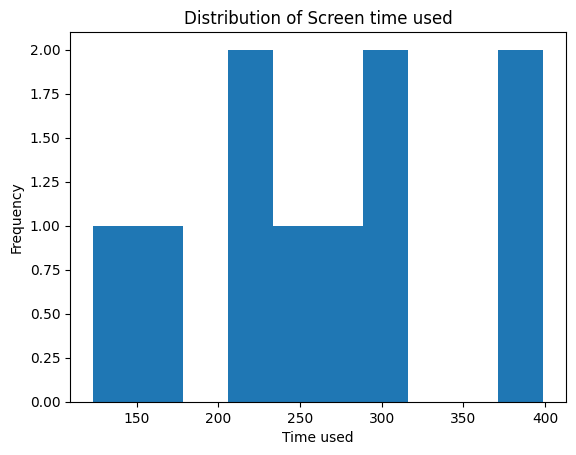

In [93]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

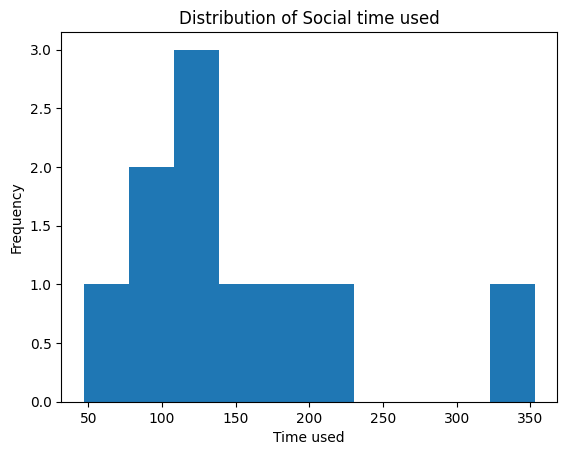

In [94]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Social time used")
plt.show

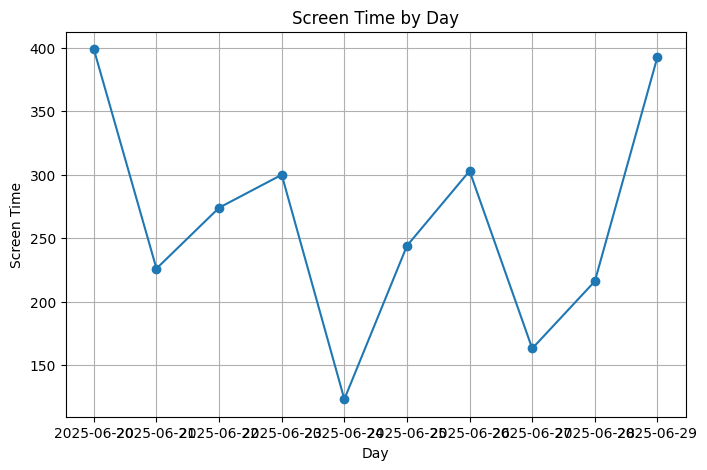

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.grid(True)
plt.show()

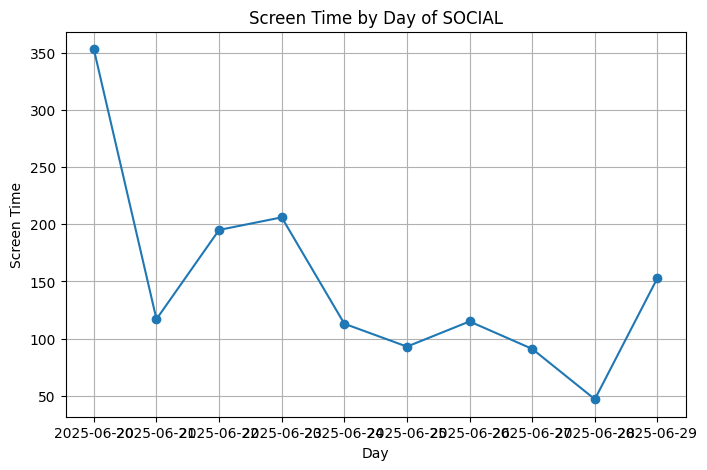

In [96]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL')
plt.grid(True)
plt.show()

$z$-score

In [97]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,OTHERS,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,46.0,1.589669,2.493893
1,2025-06-21,226.0,117.0,109.0,-0.448973,-0.381333
2,2025-06-22,274.0,195.0,79.0,0.116662,0.568954
3,2025-06-23,300.0,206.0,94.0,0.423048,0.702968
4,2025-06-24,123.0,113.0,10.0,-1.662731,-0.430066


Chebyshev's theorem

In [98]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107


# EATING LOG